In [2]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn import set_config; set_config(display='diagram')
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import SelectPercentile, VarianceThreshold, SelectFromModel, mutual_info_classif

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [3]:
from src.getdata_utils import load_data, split_data

In [4]:
filepath="../data/bank-full.csv"
df = pd.read_csv(filepath, sep=';', header=0)
df[df['y'] == 'yes'].head(50)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
83,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
86,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
87,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
129,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
168,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
270,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
388,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
390,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
446,39,technician,single,unknown,no,45248,yes,no,unknown,6,may,1623,1,-1,0,unknown,yes
457,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes


In [5]:
import numpy as np
import pandas as pd

# ===== START FROM your original df (contains duration, balance, pdays, campaign, previous, etc.) =====
# df = ...  # your original dataframe

df3 = df.copy()

# 1) Remove leakage column
df3 = df3.drop(columns=["duration"], errors="ignore")

# 2) Create log_balance (safe for zeros/negatives), drop raw balance
if "balance" in df3.columns:
    shift = 1 - df3["balance"].min() if df3["balance"].min() <= 0 else 0
    df3["log_balance"] = np.log(df3["balance"] + shift)
    df3 = df3.drop(columns=["balance"])

# 3) pdays → categorical buckets (explicit labels)
def pdays_category(x):
    if x == -1:
        return "not_contacted"
    elif 0 <= x <= 7:
        return "recent_within_week"       # 0–7 days ago
    elif 8 <= x <= 30:
        return "last_month"               # 8–30 days ago
    else:
        return "contacted_over_30_days"   # >30 days ago

if "pdays" in df3.columns:
    df3["pdays_cat"] = df3["pdays"].apply(pdays_category)
    df3 = df3.drop(columns=["pdays"])

# 4) campaign → rename & bucket like previous style
def campaign_category(x):
    if x == 1:
        return "first_contact"
    elif x == 2:
        return "second_contact"
    elif 3 <= x <= 5:
        return "atleast_3_times"
    elif 6 <= x <= 10:
        return "atleast_6_times"
    else:
        return "more_than_10_times"

if "campaign" in df3.columns:
    df3 = df3.rename(columns={"campaign": "Current_Campaign_Contact"})
    df3["Current_Campaign_Contact_cat"] = df3["Current_Campaign_Contact"].apply(campaign_category)
    df3 = df3.drop(columns=["Current_Campaign_Contact"])

# 5) previous → rename & bucket using your exact labels
def previous_category(x):
    if x == 0:
        return "no_previous_contact"
    elif 1 <= x <= 2:
        return "atleast_twice"
    elif 3 <= x <= 5:
        return "atleast_3_times"
    else:
        return "more_than_5_times"

if "previous" in df3.columns:
    df3 = df3.rename(columns={"previous": "Previous_Campaign_Contact"})
    df3["Previous_Campaign_Contact_cat"] = df3["Previous_Campaign_Contact"].apply(previous_category)
    df3 = df3.drop(columns=["Previous_Campaign_Contact"])

# 6) Age bins (middle_age starts at 40)
if "age" in df3.columns:
    age_bins   = [18, 25, 39, 45, 60, 95]  # inclusive on right
    age_labels = ["young_adult", "adult", "middle_age", "mature_adult", "senior"]
    df3["age_bin"] = pd.cut(df3["age"], bins=age_bins, labels=age_labels, right=True, include_lowest=True)

# (Optional) Make obvious categoricals dtype 'category' (helps memory & clarity)
cat_cols = [
    "job", "marital", "education", "default", "housing", "loan",
    "contact", "month",
    "poutcome",
    "pdays_cat",
    "Current_Campaign_Contact_cat",
    "Previous_Campaign_Contact_cat",
    "age_bin",
    "y"
]
for c in cat_cols:
    if c in df3.columns:
        df3[c] = df3[c].astype("category")

# Final output
df3_ready = df3.copy()

# Save a copy (optional)
#df3_ready.to_csv("bank_df3_ready.csv", index=False)
print("df3_ready shape:", df3_ready.shape)
print("Saved: bank_df3_ready.csv")

# Quick sanity checks (optional)
for col in ["pdays_cat", "Current_Campaign_Contact_cat", "Previous_Campaign_Contact_cat", "age_bin"]:
    if col in df3_ready.columns:
        print(f"\n{col} distribution:")
        print(df3_ready[col].value_counts(dropna=False))


df3_ready shape: (45211, 17)
Saved: bank_df3_ready.csv

pdays_cat distribution:
pdays_cat
not_contacted             36954
contacted_over_30_days     8069
last_month                  105
recent_within_week           83
Name: count, dtype: int64

Current_Campaign_Contact_cat distribution:
Current_Campaign_Contact_cat
first_contact         17544
second_contact        12505
atleast_3_times       10807
atleast_6_times        3159
more_than_10_times     1196
Name: count, dtype: int64

Previous_Campaign_Contact_cat distribution:
Previous_Campaign_Contact_cat
no_previous_contact    36954
atleast_twice           4878
atleast_3_times         2315
more_than_5_times       1064
Name: count, dtype: int64

age_bin distribution:
age_bin
adult           22026
mature_adult    13260
middle_age       7401
young_adult      1336
senior           1188
Name: count, dtype: int64


In [6]:
df3_ready.head()

,age,job,marital,education,default,housing,loan,contact,day,month,poutcome,y,log_balance,pdays_cat,Current_Campaign_Contact_cat,Previous_Campaign_Contact_cat,age_bin
0,58,management,married,tertiary,no,yes,no,unknown,5,may,unknown,no,9.226509,not_contacted,first_contact,no_previous_contact,mature_adult
1,44,technician,single,secondary,no,yes,no,unknown,5,may,unknown,no,8.993303,not_contacted,first_contact,no_previous_contact,middle_age
2,33,entrepreneur,married,secondary,no,yes,yes,unknown,5,may,unknown,no,8.989943,not_contacted,first_contact,no_previous_contact,adult
3,47,blue-collar,married,unknown,no,yes,no,unknown,5,may,unknown,no,9.161780,not_contacted,first_contact,no_previous_contact,mature_adult
4,33,unknown,single,unknown,no,no,no,unknown,5,may,unknown,no,8.989818,not_contacted,first_contact,no_previous_contact,adult


In [7]:
# Drop raw age (keep age_bin only)
df3_ready = df3_ready.drop(columns=["age"])

print("Shape after dropping age:", df3_ready.shape)
print("Remaining columns:", df3_ready.columns.tolist())


Shape after dropping age: (45211, 16)
Remaining columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day', 'month', 'poutcome', 'y', 'log_balance', 'pdays_cat', 'Current_Campaign_Contact_cat', 'Previous_Campaign_Contact_cat', 'age_bin']


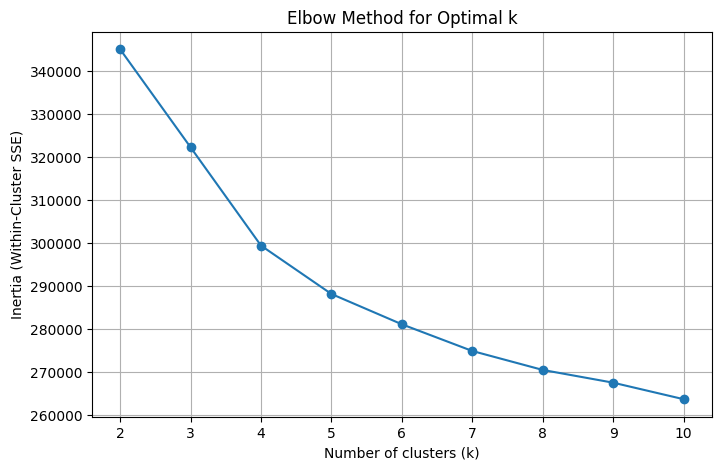

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Drop target column 'y' if present
df_cluster = df3_ready.drop(columns=["y"], errors="ignore")

# 2. Identify categorical vs numeric features
numeric_features = ["log_balance"]
categorical_features = [col for col in df_cluster.columns if col not in numeric_features]

# 3. Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# 4. Elbow method
inertia = []
K = range(2, 11)

for k in K:
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("kmeans", KMeans(n_clusters=k, random_state=42, n_init=10))
    ])
    model.fit(df_cluster)
    inertia.append(model.named_steps["kmeans"].inertia_)

# 5. Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (Within-Cluster SSE)")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()


In [9]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

# Drop target 'y' for clustering
df_cluster = df3_ready.drop(columns=["y"], errors="ignore")

# Separate numeric vs categorical
numeric_features = ["log_balance"]
categorical_features = [c for c in df_cluster.columns if c not in numeric_features]

# Preprocessor
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Final KMeans model
kmeans_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("kmeans", KMeans(n_clusters=4, random_state=42, n_init=10))
])

# Fit model
kmeans_pipe.fit(df_cluster)

# Assign cluster labels back to dataframe
df_clusters = df3_ready.copy()
df_clusters["cluster"] = kmeans_pipe.named_steps["kmeans"].labels_

# Check cluster sizes
print(df_clusters["cluster"].value_counts().sort_index())


cluster
0    18560
1     7789
2    15267
3     3595
Name: count, dtype: int64


In [12]:
import pandas as pd
import numpy as np

# =========================================================
# 0) INPUT: df_clusters must already exist with a 'cluster' column
# =========================================================
assert "cluster" in df_clusters.columns, "df_clusters must contain a 'cluster' column."

# Make sure cluster is clean int for grouping/printing
df_clusters = df_clusters.copy()
df_clusters["cluster"] = df_clusters["cluster"].astype(int)

# Identify columns
target_col = "y" if "y" in df_clusters.columns else None

# Numeric: all numeric except 'cluster'
num_cols = [c for c in df_clusters.select_dtypes(include=[np.number]).columns if c != "cluster"]

# Categorical: object or category (excluding 'cluster' and target 'y')
cat_cols = [
    c for c in df_clusters.columns
    if (df_clusters[c].dtype.name in ("object", "category")) and c not in {"cluster", target_col}
]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

# =========================================================
# 1) Cluster sizes
# =========================================================
print("\n=== Cluster sizes ===")
cluster_sizes = df_clusters["cluster"].value_counts().sort_index()
try:
    display(cluster_sizes.to_frame("count"))
except NameError:
    print(cluster_sizes.to_frame("count"))

# =========================================================
# 2) Target (y) rate by cluster — robust to categorical dtype
# =========================================================
if target_col:
    print("\n=== Target (y) rate by cluster ===")
    y_str = df_clusters[target_col].astype(str).str.lower().str.strip()
    # yes -> 1.0, everything else -> 0.0 (including 'no', NaN, odd labels)
    y_bin = y_str.eq("yes").astype(float)
    target_rate = df_clusters.assign(y_bin=y_bin).groupby("cluster")["y_bin"].mean()
    y_rate_df = (target_rate * 100).round(2).to_frame("y_rate_%")
    try:
        display(y_rate_df)
    except NameError:
        print(y_rate_df)

# =========================================================
# 3) Numeric feature summary by cluster
# =========================================================
if num_cols:
    print("\n=== Numeric summary by cluster ===")
    num_summary = df_clusters.groupby("cluster")[num_cols].agg(
        ["mean", "median", "std", "min", "max", "count"]
    )
    try:
        display(num_summary)
    except NameError:
        print(num_summary)

# =========================================================
# 4) Categorical breakdowns (percentage within cluster)
#    For each categorical column, show % per category (rows=clusters, cols=categories)
# =========================================================
cat_tables = {}
for col in cat_cols:
    ct = pd.crosstab(df_clusters["cluster"], df_clusters[col], normalize="index") * 100.0
    ct = ct.round(1)
    cat_tables[col] = ct
    print(f"\n=== {col} (% within cluster) ===")
    try:
        display(ct)
    except NameError:
        print(ct)

# Also ensure we include your key engineered categoricals if present
for special in ["pdays_cat", "Current_Campaign_Contact_cat", "Previous_Campaign_Contact_cat", "age_bin"]:
    if special in df_clusters.columns and special not in cat_tables:
        ct = pd.crosstab(df_clusters["cluster"], df_clusters[special], normalize="index") * 100.0
        ct = ct.round(1)
        cat_tables[special] = ct
        print(f"\n=== {special} (% within cluster) ===")
        try:
            display(ct)
        except NameError:
            print(ct)

# =========================================================
# 5) Export CSVs (optional)
# =========================================================
out_prefix = "kmeans4_profiles"
cluster_sizes.to_csv(f"{out_prefix}__sizes.csv")
if target_col:
    y_rate_df.to_csv(f"{out_prefix}__target_rate.csv")
if num_cols:
    num_summary.to_csv(f"{out_prefix}__numeric_summary.csv")
for col, table in cat_tables.items():
    table.to_csv(f"{out_prefix}__{col}_breakdown.csv")

print("\nSaved CSVs with prefix:", out_prefix)


Numeric columns: ['day', 'log_balance']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'pdays_cat', 'Current_Campaign_Contact_cat', 'Previous_Campaign_Contact_cat', 'age_bin']

=== Cluster sizes ===


,count
cluster,
0,18560
1,7789
2,15267
3,3595



=== Target (y) rate by cluster ===


,y_rate_%
cluster,
0,6.23
1,22.63
2,11.97
3,15.08



=== Numeric summary by cluster ===


...


=== Previous_Campaign_Contact_cat (% within cluster) ===


Previous_Campaign_Contact_cat,atleast_3_times,atleast_twice,more_than_5_times,no_previous_contact
cluster,,,,
0,0.0,0.0,0.0,100.0
1,27.8,59.3,12.9,0.0
2,0.0,0.0,0.0,100.0
3,4.1,7.3,1.6,87.0



=== age_bin (% within cluster) ===


age_bin,young_adult,adult,middle_age,mature_adult,senior
cluster,,,,,
0,3.2,54.8,18.2,23.7,0.2
1,3.1,52.0,15.3,24.5,5.0
2,3.0,41.6,14.6,37.0,3.8
3,1.4,40.4,16.9,36.2,5.2



Saved CSVs with prefix: kmeans4_profiles


In [17]:
# Define mapping
cluster_names = {
    1: "Best conversion: warm re-contacts, educated (Highest term Deposit rate)",
    0: "Blue-collar first-timers, housing loans (low ROI)",
    2: "New affluent/older prospects (test offers)",
    3: "Older management professionals (secondary target)"
}

# Map to new column
df_clusters["cluster_label"] = df_clusters["cluster"].map(cluster_names)

# Check result
print(df_clusters[["cluster", "cluster_label"]].head(10))
print("\nCluster counts:")
print(df_clusters["cluster_label"].value_counts())


   cluster                                      cluster_label
0        0  Blue-collar first-timers, housing loans (low ROI)
1        0  Blue-collar first-timers, housing loans (low ROI)
2        0  Blue-collar first-timers, housing loans (low ROI)
3        0  Blue-collar first-timers, housing loans (low ROI)
4        2         New affluent/older prospects (test offers)
5        0  Blue-collar first-timers, housing loans (low ROI)
6        0  Blue-collar first-timers, housing loans (low ROI)
7        0  Blue-collar first-timers, housing loans (low ROI)
8        0  Blue-collar first-timers, housing loans (low ROI)
9        0  Blue-collar first-timers, housing loans (low ROI)

Cluster counts:
cluster_label
Blue-collar first-timers, housing loans (low ROI)                          18560
New affluent/older prospects (test offers)                                 15267
Best conversion: warm re-contacts, educated (Highest term Deposit rate)     7789
Older management professionals (secondary ta

🔎 Cluster Profiles (k=4)
Cluster 0 (18,560 clients, ~41%)

Target rate (y): 6.2% → very low

Demographics: Mostly adults (26–39, 55%), then middle_age (18%) and mature_adult (24%). Almost no seniors.

Jobs: Blue-collar (29%), management (17%), technician (16%), admin (13%).

Contacts: All not_contacted previously (100%), and all poutcome unknown.

Campaign: Mix of first_contact (38%) and second_contact (27%).

Loans: Housing loan ~100% (!!), 18% have personal loans.

Interpretation:
→ Newly targeted blue-collar/management adults with housing loans. Very hard to convert (low y). Likely “mass market, first outreach”.


Cluster 1 (7,789 clients, ~17%)-warm re-contacts with strong education. Focus resources here

Target rate (y): 22.6% → highest of all clusters

Demographics: Balanced adults (52%), mature_adults (25%), with more seniors (5%).

Jobs: More management (21%), strong technician/admin presence.

Education: Highest tertiary (31%) share.

Contacts: Previously contacted (pdays=contacted_over_30_days = 98%); poutcome mix of failure (60%), success (18%).

Campaign: Mostly first_contact (49%) and second (28%).

Loans: Housing 63% yes, 14% loan yes.

Interpretation:
→ Re-contacted, educated professionals with prior campaign history. This is your “warm leads” cluster — highest conversion potential.


Cluster 2 (15,267 clients, ~34%)

Target rate (y): 12%

Demographics: Stronger mature adults (37%), some seniors (4%). Adults (42%).

Jobs: Management-heavy (23%), technician (18%), retired (8%).

Contacts: All not_contacted before, poutcome unknown.

Campaign: Balanced mix of contacts, not just first.

Loans: No housing loans (100% “no”), 16% loans.

Interpretation:
→ New targets but wealthier/older (management, retired). Moderate response rate. Could be your “affluent first-time targets” cluster.


Cluster 3 (3,595 clients, ~8%)

Target rate (y): 15.1%

Demographics: Skews older (36% mature_adults, 5% seniors), fewer young adults.

Jobs: Management-heavy (30%), then technician/admin ~16%.

Contacts: Mostly not_contacted (87%), but some re-contacts (13%). Poutcome: mostly unknown.

Loans: Housing mix (54% no, 46% yes), loans low (7%).

Campaign: Mostly first_contact (40%), with some repeat.

Interpretation:
→ Older, management-heavy prospects with mixed housing status. Decent y-rate. Could be “senior professionals” cluster.

✅ Takeaways

Cluster 1 = Best conversion (22.6%), warm re-contacts with strong education. Focus resources here.

Cluster 0 = Blue-collar first-timers with housing loans. Low ROI, deprioritize.

Cluster 2 = New affluent/older prospects. Worth testing with specialized offers.

Cluster 3 = Older management professionals, decent response. Good secondary target.

Blue-collar first-timers, housing loans (low ROI)


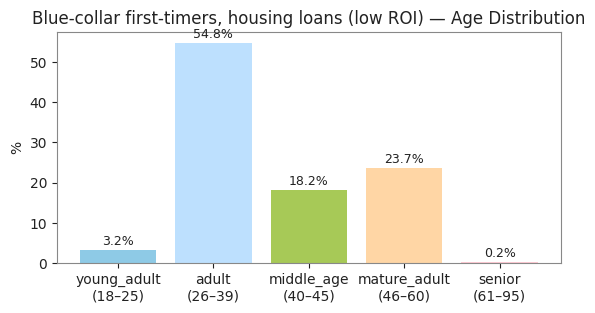

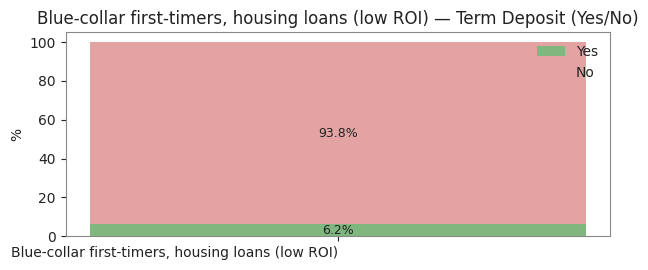

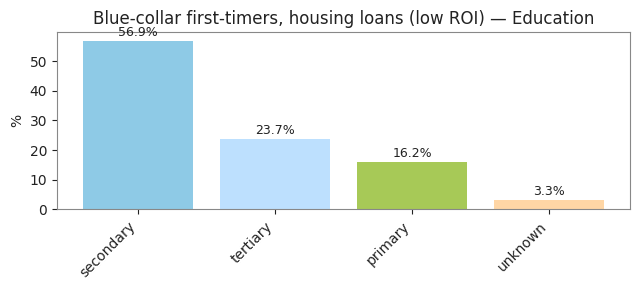

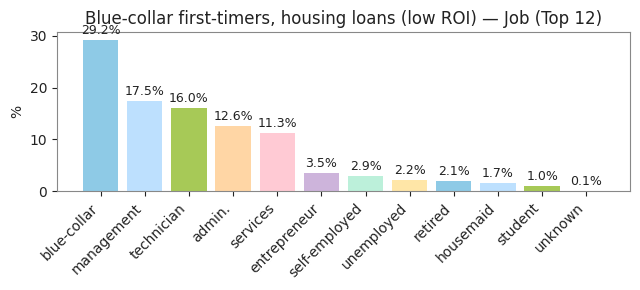

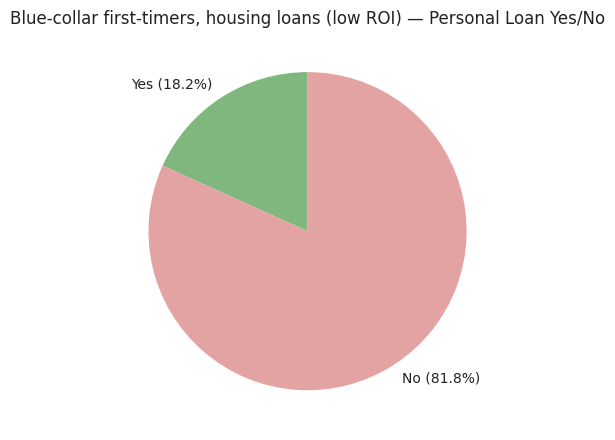

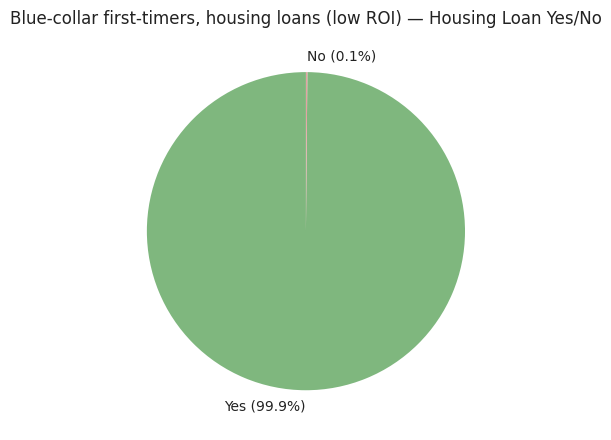

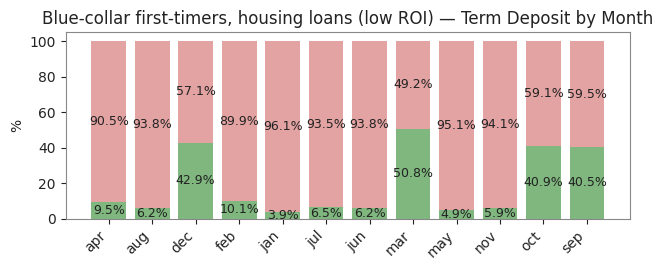

New affluent/older prospects (test offers)


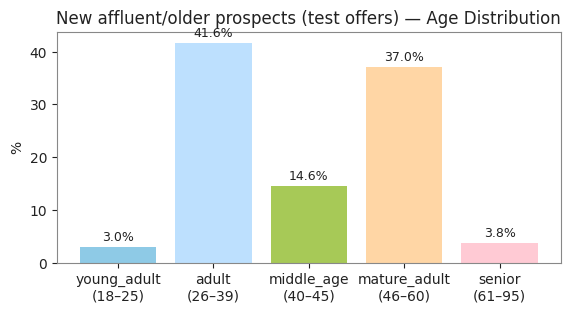

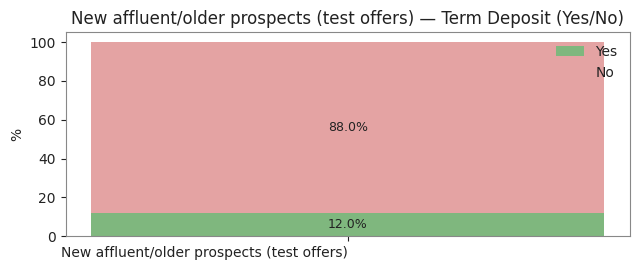

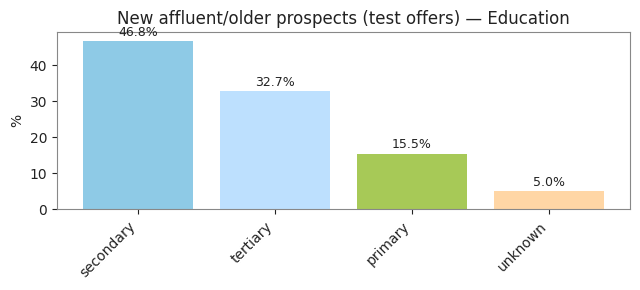

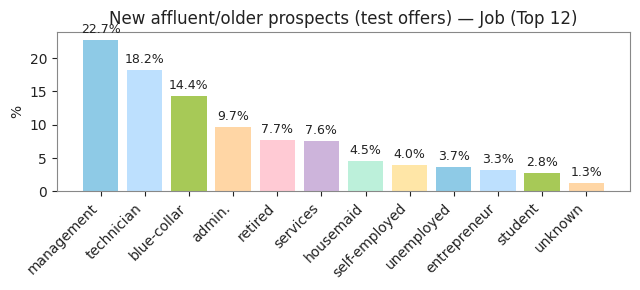

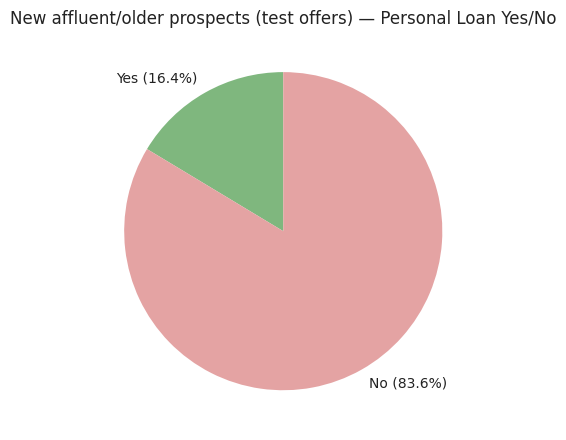

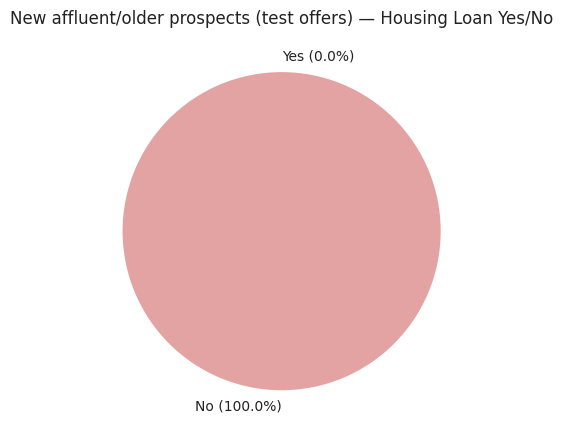

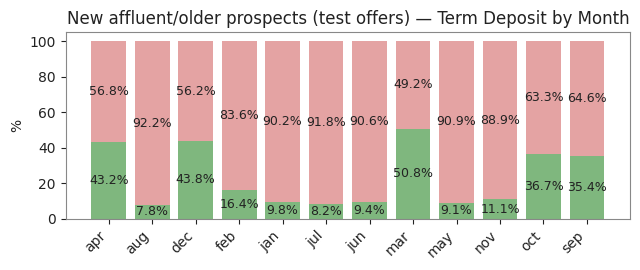

Older management professionals (secondary target)


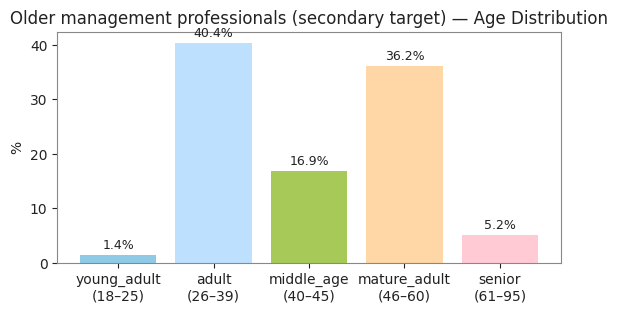

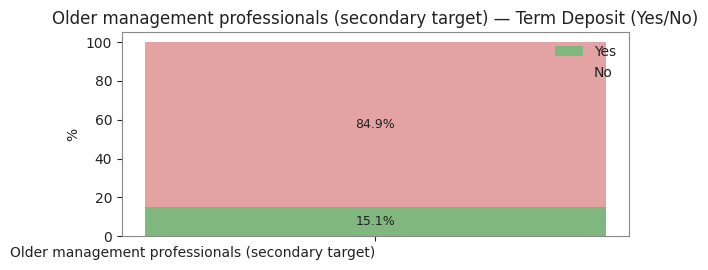

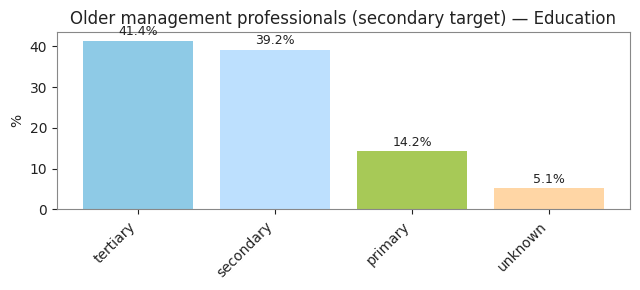

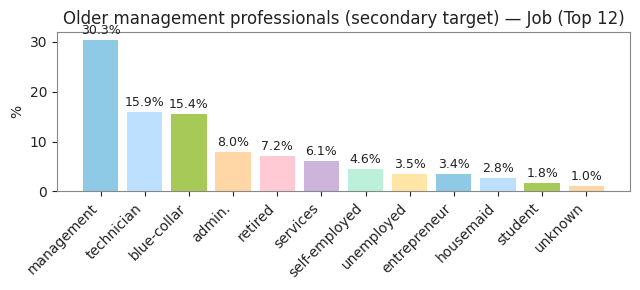

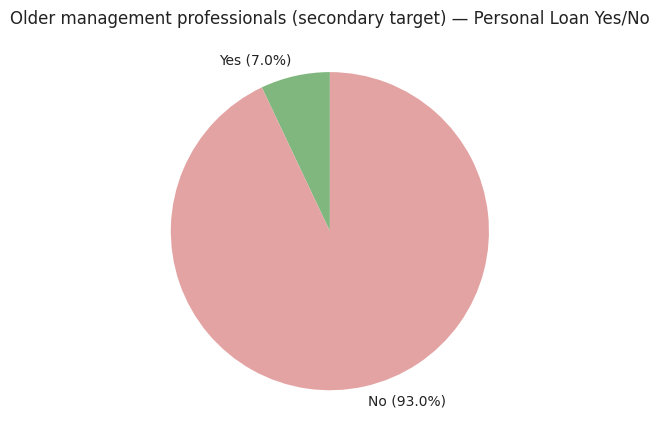

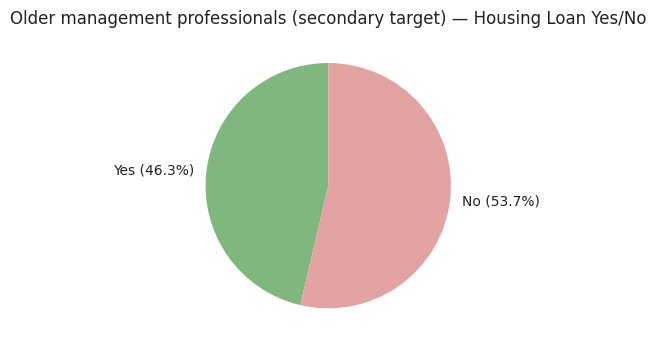

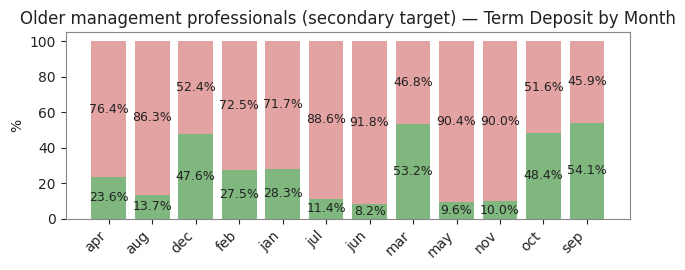

Best conversion: warm re-contacts, educated (Highest term Deposit rate)


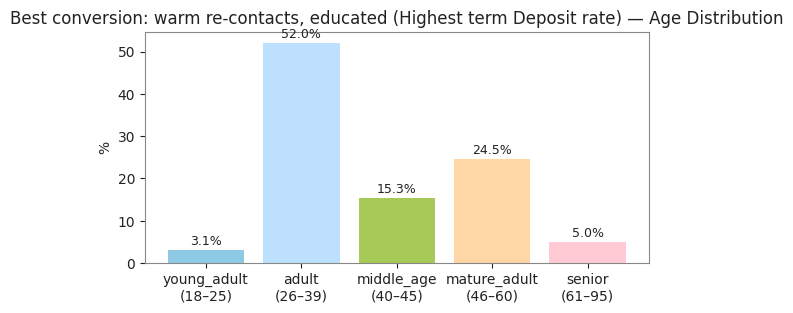

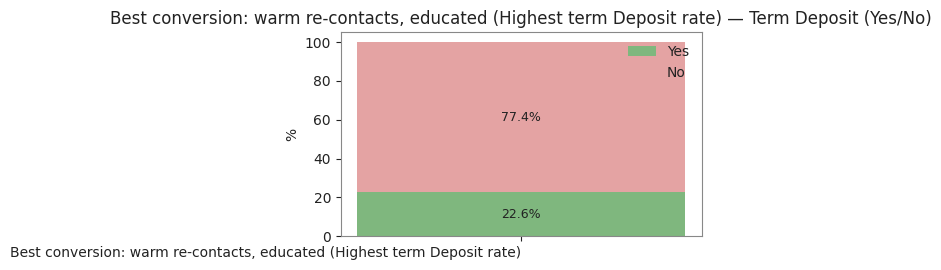

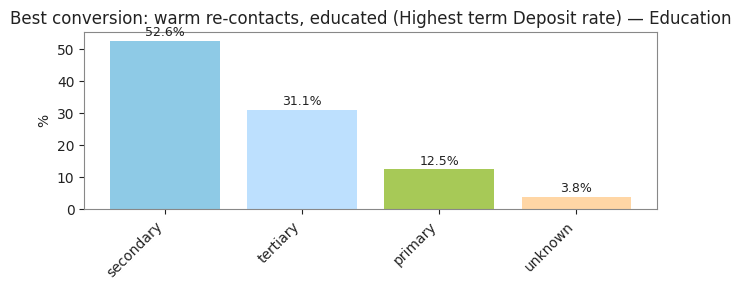

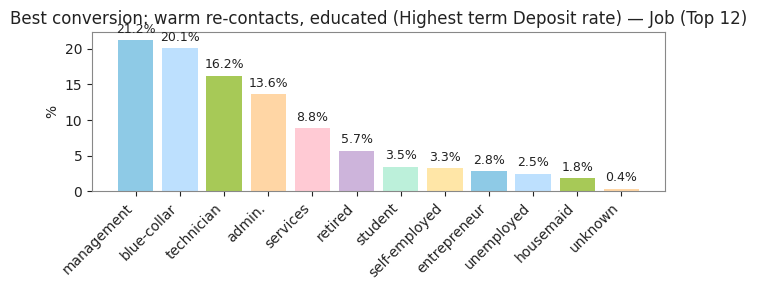

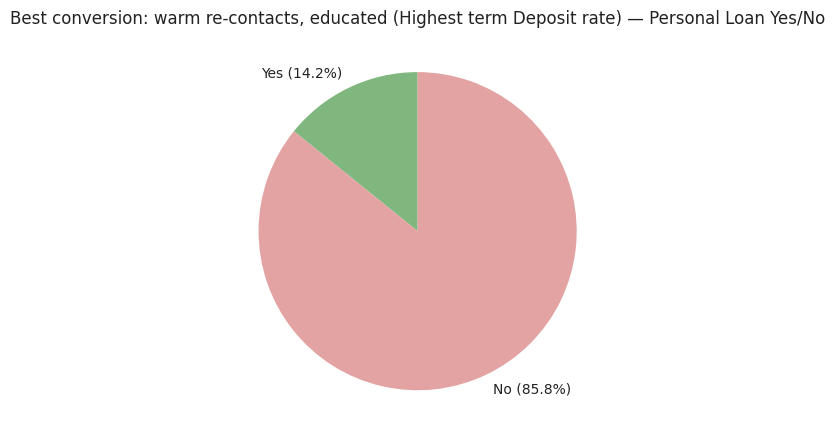

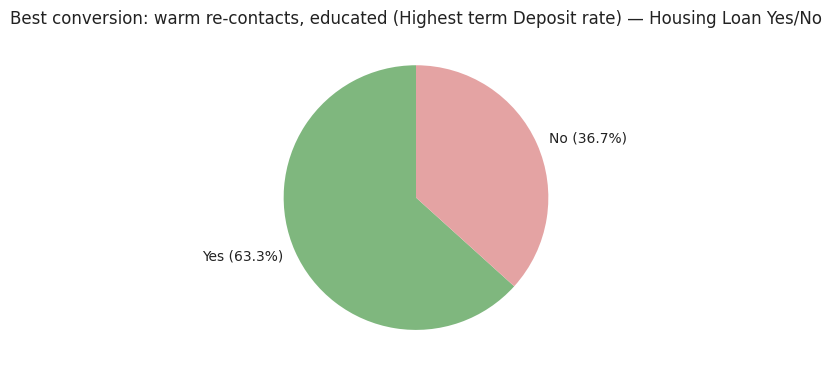

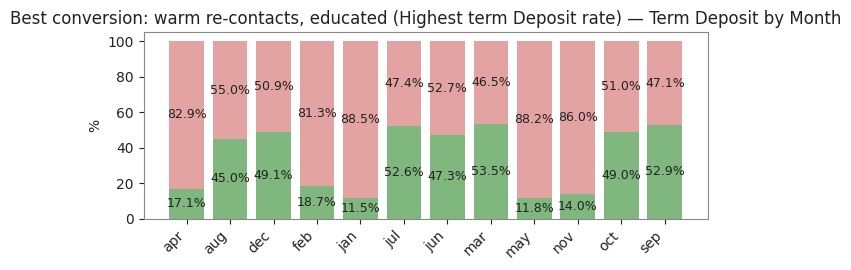

In [18]:
# === Compact inline "page per cluster" (no PNGs) ===
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

assert 'df_clusters' in globals(), "Please run AFTER df_clusters is created."

# Mild colors (as requested)
COLS = ["#8ecae6", "#bde0fe", "#a7c957", "#ffd6a5", "#ffcad4", "#cdb4db", "#bcf0da", "#ffe6a7"]
COL_YES, COL_NO = "#7FB77E", "#E4A3A3"

plt.rcParams.update({
    "figure.facecolor": "#FFFFFF",
    "axes.facecolor": "#FFFFFF",
    "axes.edgecolor": "#888888",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "font.size": 10
})

def pct_series(s):
    c = s.value_counts(dropna=False)
    return (c / c.sum() * 100).sort_values(ascending=False)

def show_age_bins(df, clab):
    order  = ["young_adult","adult","middle_age","mature_adult","senior"]
    ranges = {"young_adult":"18–25","adult":"26–39","middle_age":"40–45","mature_adult":"46–60","senior":"61–95"}
    s = df["age_bin"].astype(str)
    idx = [lab for lab in order if lab in s.unique()]
    pct = (s.value_counts(normalize=True)*100).reindex(idx).fillna(0)
    fig = plt.figure(figsize=(6.5, 3.0))
    x = np.arange(len(pct))
    colors = (COLS * ((len(pct)//len(COLS))+1))[:len(pct)]
    plt.bar(x, pct.values, color=colors)
    # Put age ranges with labels
    plt.xticks(x, [f"{lab}\n({ranges.get(lab,'')})" for lab in pct.index])
    plt.ylabel("%")
    plt.title(f"{clab} — Age Distribution")
    for i, v in enumerate(pct.values):
        plt.text(i, v + 0.6, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.show()

def show_target_stack(df, title, group_col):
    sub = df[[group_col, "y"]].copy()
    sub["y_norm"] = sub["y"].astype(str).str.lower().str.strip().map({"yes":"yes","no":"no"})
    tab = pd.crosstab(sub[group_col], sub["y_norm"], normalize="index")*100
    for lab in ["yes","no"]:
        if lab not in tab.columns: tab[lab] = 0.0
    tab = tab[["yes","no"]]
    fig = plt.figure(figsize=(6.5, 2.8))
    x = np.arange(len(tab))
    plt.bar(x, tab["yes"], color=COL_YES, label="Yes")
    plt.bar(x, tab["no"], bottom=tab["yes"], color=COL_NO, label="No")
    plt.xticks(x, tab.index, rotation=0 if group_col=="cluster_label" else 45, ha="right")
    plt.ylabel("%")
    plt.title(title)
    for i,(yv,nv) in enumerate(zip(tab["yes"].values, tab["no"].values)):
        if yv>0: plt.text(i, yv/2, f"{yv:.1f}%", ha="center", va="center", fontsize=9)
        if nv>0: plt.text(i, yv+nv/2, f"{nv:.1f}%", ha="center", va="center", fontsize=9)
    if group_col=="cluster_label":
        plt.legend(frameon=False, loc="upper right")
    plt.tight_layout()
    plt.show()

def show_bar_sorted(df, col, title, top_n=None):
    pct = pct_series(df[col].astype(str).str.strip())
    if top_n: pct = pct.head(top_n)
    fig = plt.figure(figsize=(6.5, 3.0))
    x = np.arange(len(pct))
    colors = (COLS * ((len(pct)//len(COLS))+1))[:len(pct)]
    plt.bar(x, pct.values, color=colors)
    plt.xticks(x, pct.index, rotation=45, ha="right")
    plt.ylabel("%")
    plt.title(title)
    for i, v in enumerate(pct.values):
        plt.text(i, v + 0.6, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

def show_pie_yes_no(df, col, title):
    s = df[col].astype(str).str.lower().str.strip().map({"yes":"Yes","no":"No"})
    cnt = s.value_counts()
    for lab in ["Yes","No"]:
        if lab not in cnt.index: cnt.loc[lab] = 0
    cnt = cnt[["Yes","No"]]
    fig = plt.figure(figsize=(4.5, 4.5))
    plt.pie(cnt.values,
            labels=[f"{lab} ({cnt[lab]/cnt.sum()*100:.1f}%)" for lab in cnt.index],
            startangle=90, colors=[COL_YES, COL_NO])
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---- Display a compact "page" for each cluster (sequence of compact charts) ----
for clab in df_clusters["cluster_label"].unique():
    sub = df_clusters[df_clusters["cluster_label"] == clab].copy()
    print("="*90)
    print(clab)
    print("="*90)
    # Row 1
    show_age_bins(sub, clab)
    show_target_stack(sub, f"{clab} — Term Deposit (Yes/No)", group_col="cluster_label")
    # Row 2
    show_bar_sorted(sub, "education", f"{clab} — Education")
    show_bar_sorted(sub, "job", f"{clab} — Job (Top 12)", top_n=12)
    # Row 3
    show_pie_yes_no(sub, "loan",    f"{clab} — Personal Loan Yes/No")
    show_pie_yes_no(sub, "housing", f"{clab} — Housing Loan Yes/No")
    # Row 4
    show_target_stack(sub, f"{clab} — Term Deposit by Month", group_col="month")


In [19]:
# Export only Cluster 1 (Best conversion: warm re-contacts)
cluster1 = df_clusters[df_clusters["cluster_label"].str.startswith("Best conversion")]

# Save to CSV
cluster1.to_csv("cluster1_best_conversion.csv", index=False)

print("Saved:", "cluster1_best_conversion.csv", "with shape", cluster1.shape)


Saved: cluster1_best_conversion.csv with shape (7789, 18)
